<a href="https://colab.research.google.com/github/rohanbhangale/mldl_exps/blob/main/mldl_exp_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - accuracy: 0.8120 - loss: 0.3991 - val_accuracy: 0.8602 - val_loss: 0.3333
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 78ms/step - accuracy: 0.8799 - loss: 0.2859 - val_accuracy: 0.8619 - val_loss: 0.3137
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 82ms/step - accuracy: 0.8997 - loss: 0.2460 - val_accuracy: 0.8713 - val_loss: 0.3081
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 79ms/step - accuracy: 0.9147 - loss: 0.2109 - val_accuracy: 0.8683 - val_loss: 0.3251
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 81ms/step - accuracy: 0.9284 - loss: 0.1816 - val_accuracy: 0.8599 - val_loss: 0.3450
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Accuracy: 0.8599
Confusion Matrix:
 [[4276  685]
 [ 716 4323]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86      4961
           1       0.86      0.86      0.86      5039

    accuracy                           0.86     10000
   macro

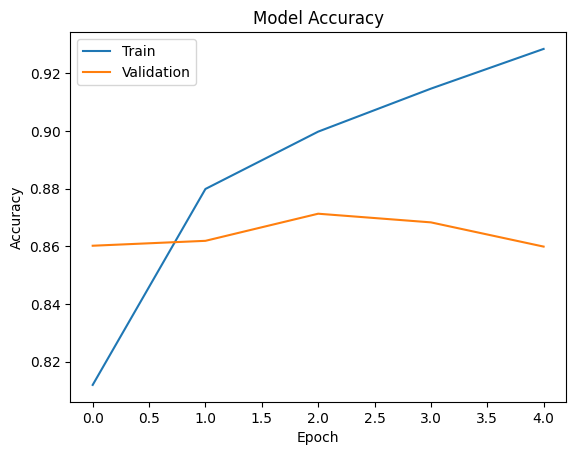

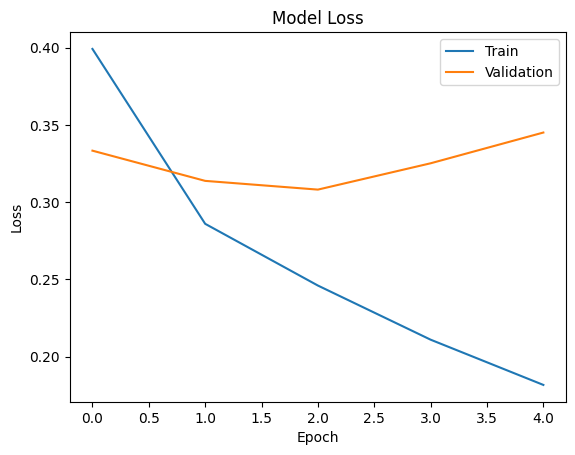

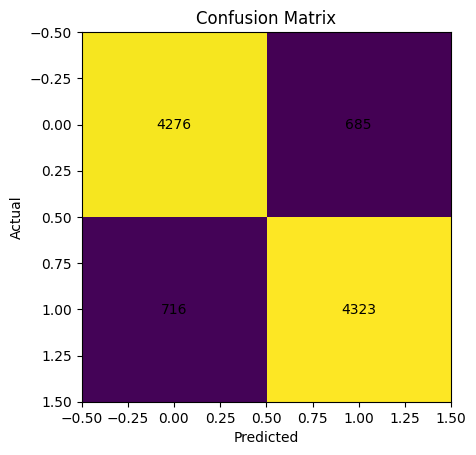

In [1]:
# =========================================
# RNN / LSTM for Text Classification
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding

# =========================================
# STEP 1: LOAD DATA
# =========================================

data = pd.read_csv("IMDB Dataset.csv")
print(data.head())

# Convert sentiment to binary
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

# =========================================
# STEP 2: TEXT PREPROCESSING
# =========================================

X = data['review']
y = data['sentiment']

# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)

# Padding
X_pad = pad_sequences(X_seq, maxlen=100)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

# =========================================
# STEP 3: BUILD LSTM MODEL
# =========================================

model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))
model.add(LSTM(units=64))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# =========================================
# STEP 4: TRAIN MODEL
# =========================================

history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# =========================================
# STEP 5: EVALUATION
# =========================================

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# =========================================
# STEP 6: VISUALIZATIONS
# =========================================

# Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss Graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

# Confusion Matrix Visualization
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()